
Matched rows (max diameter vs max hole, one per ODP subtype): 34
         F1_Name  ODP_Diameter_nm  #Radial_filaments    Shapes                 F2_Name  Hole_Diameter_nm  Diameter_Hole_Ratio
DSM2-NKB-DSM17_A       608.051797                  2 Elongated  DSM2-NKB-hole-DSM17_A1         57.688182            10.540318
DSM2-NKB-DSM17_B       590.539475                  2 Elongated  DSM2-NKB-hole-DSM17_B1         73.227258             8.064476
DSM2-NKB-DSM19_A       233.224589                  1     Ovoid  DSM2-NKB-hole-DSM19_A1         49.287011             4.731969
DSM2-NKB-DSM19_B       240.664026                  1     Ovoid  DSM2-NKB-hole-DSM19_B1         75.841189             3.173263
 DSM2-NKB-DSM2_B       743.531878                  2 Elongated   DSM2-NKB-hole-DSM2_B1         47.321498            15.712349
DSM2-NKB-DSM20_B       233.648095                  1     Ovoid  DSM2-NKB-hole-DSM20_B1         58.787229             3.974470
DSM2-NKB-DSM24_A       669.761687                  2

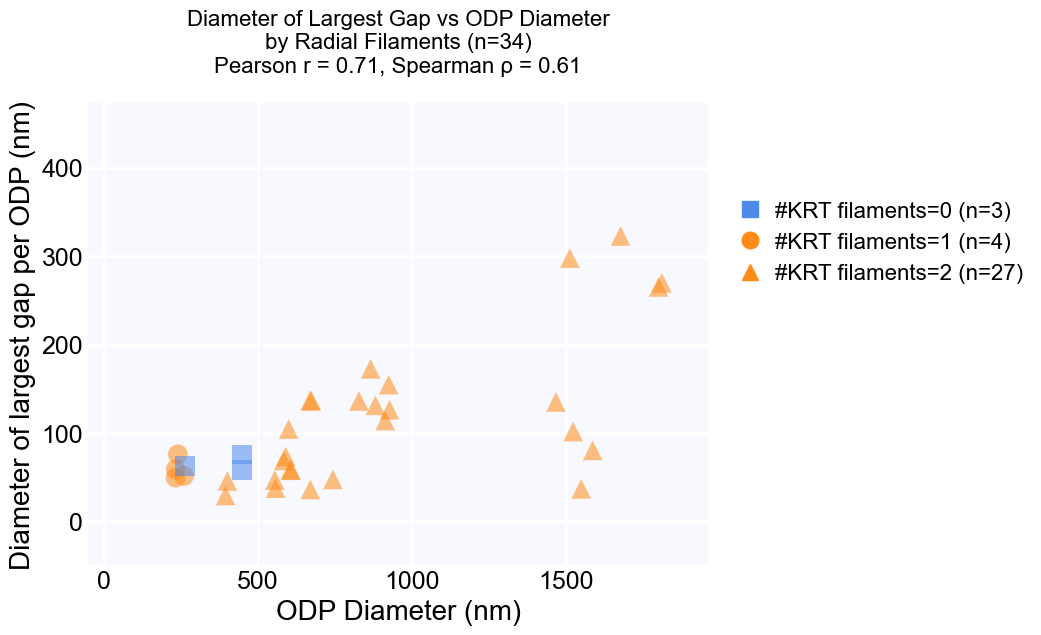

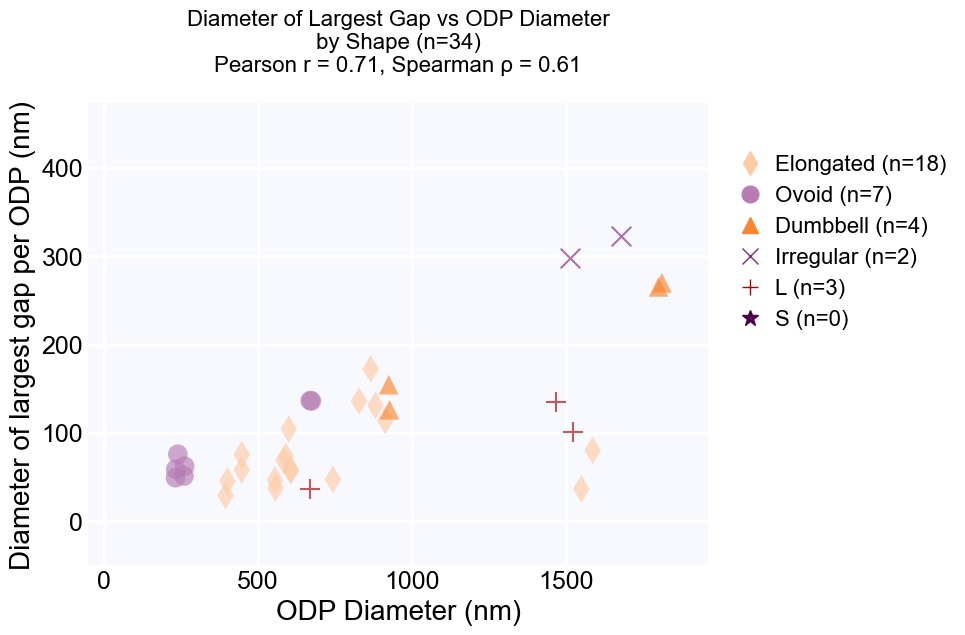

(0.7058171208991117, 0.6137509549274255)

In [1]:
# ---------------------------------------------------------------
# A431 Script 1: Hole diameter vs ODP diameter (F1 vs F2 matched, max-only)
# ---------------------------------------------------------------
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import matplotlib.lines as mlines
import numpy as np
import matplotlib

# ------------------------------
# User Settings
# ------------------------------
input_fileF1 = "260503-DSM2-DSM3-indODP-COMBINED.csv"
input_fileF2 = "260503-DSM2-DSM3-hole-COMBINED.csv"
substr = "260503-DSM2-DSM3"
output_dir = "./Output-files/"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes
# ------------------------------
title_fontsize = 16
axis_fontsize = 20
tick_fontsize = 18
legend_fontsize = 16

# ------------------------------
# Set fonts to be editable in Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize": title_fontsize,
    "axes.labelsize": axis_fontsize,
    "xtick.labelsize": tick_fontsize,
    "ytick.labelsize": tick_fontsize,
    "legend.fontsize": legend_fontsize,
})

# Scatter point transparency
alpha_val = 0.55
alpha_val_shape = 0.65

# Legend
legend_pos = (1, 0.7)
marker_size = 12

# Plot background color
background_color = "ghostwhite"

# ------------------------------
# Columns
# ------------------------------
f1_name_col     = "Name (NA)_match"
f1_diameter_col = "Corrected length"
f1_fil_col      = "#Radial_filaments"
f1_shapes_col   = "Shapes"

f2_name_col     = "Name (NA)_hole"
f2_feret_col    = "Feret Max (nm)"

substrings_to_find = ["DSM2-NKB", "DSM2-SEZ", "DSM3-COMBINED"]

# ------------------------------
# Load data
# ------------------------------
df_f1 = pd.read_csv(input_fileF1)
df_f2 = pd.read_csv(input_fileF2)

# ------------------------------
# Parsing helpers
# ------------------------------
f1_pattern = re.compile(
    r'^(DSM2-NKB|DSM2-SEZ|DSM3-COMBINED)-(DSM\d+)_([A-Z][a-z]?)$',
    re.IGNORECASE
)
f2_pattern = re.compile(
    r'^(DSM2-NKB|DSM2-SEZ|DSM3-COMBINED)-hole-(DSM\d+)_([A-Z])(\d+)$',
    re.IGNORECASE
)

def parse_f1_label(label):
    m = f1_pattern.match(str(label).strip())
    if not m:
        return None
    prefix, dsm_id, subtype = m.group(1), m.group(2), m.group(3)
    return {"prefix": prefix.upper(), "dsm_id": dsm_id.upper(),
            "subtype": subtype, "letter": subtype[0].upper()}

def parse_f2_label(label):
    m = f2_pattern.match(str(label).strip())
    if not m:
        return None
    prefix, dsm_id, letter, num = m.group(1), m.group(2), m.group(3), m.group(4)
    return {"prefix": prefix.upper(), "dsm_id": dsm_id.upper(),
            "letter": letter.upper(), "num": int(num)}

# ------------------------------
# Parse F1 — keep max diameter per (prefix, dsm_id, letter)
# ------------------------------
f1_records = []
for _, row in df_f1.iterrows():
    parsed = parse_f1_label(row[f1_name_col])
    if parsed is None:
        continue
    if not any(s.upper() in parsed["prefix"] for s in substrings_to_find):
        continue
    f1_records.append({
        "f1_name":  row[f1_name_col],
        "prefix":   parsed["prefix"],
        "dsm_id":   parsed["dsm_id"],
        "letter":   parsed["letter"],
        "diameter": row[f1_diameter_col],
        "fil":      row[f1_fil_col],
        "shape":    row[f1_shapes_col],
    })

df_f1_parsed = pd.DataFrame(f1_records)

df_f1_max = (
    df_f1_parsed
    .sort_values("diameter", ascending=False)
    .groupby(["prefix", "dsm_id", "letter"], as_index=False)
    .first()
)

f1_lookup = {
    (r["prefix"], r["dsm_id"], r["letter"]): r
    for _, r in df_f1_max.iterrows()
}

# ------------------------------
# Parse F2 — max Feret per group
# ------------------------------
f2_records = []
for _, row in df_f2.iterrows():
    parsed = parse_f2_label(row[f2_name_col])
    if parsed is None:
        continue
    if not any(s.upper() in parsed["prefix"] for s in substrings_to_find):
        continue
    f2_records.append({
        "f2_name": row[f2_name_col],
        "prefix":  parsed["prefix"],
        "dsm_id":  parsed["dsm_id"],
        "letter":  parsed["letter"],
        "feret":   row[f2_feret_col],
    })

df_f2_parsed = pd.DataFrame(f2_records)

df_f2_max = (
    df_f2_parsed
    .sort_values("feret", ascending=False)
    .groupby(["prefix", "dsm_id", "letter"], as_index=False)
    .first()
)

# ------------------------------
# Match F1 max to F2 max
# ------------------------------
matched_rows = []
for _, f2_row in df_f2_max.iterrows():
    key = (f2_row["prefix"], f2_row["dsm_id"], f2_row["letter"])
    if key not in f1_lookup:
        continue
    f1_row = f1_lookup[key]
    diameter = f1_row["diameter"]
    feret    = f2_row["feret"]
    ratio    = diameter / feret if feret and feret != 0 else np.nan
    matched_rows.append({
        "F1_Name":             f1_row["f1_name"],
        "ODP_Diameter_nm":     diameter,
        "#Radial_filaments":   f1_row["fil"],
        "Shapes":              f1_row["shape"],
        "F2_Name":             f2_row["f2_name"],
        "Hole_Diameter_nm":    feret,
        "Diameter_Hole_Ratio": ratio,
    })

matched_df = pd.DataFrame(matched_rows)

# ------------------------------
# Print preview
# ------------------------------
print(f"\nMatched rows (max diameter vs max hole, one per ODP subtype): {len(matched_df)}")
print(matched_df.head(10).to_string(index=False))

# ------------------------------
# Save to Excel
# ------------------------------
excel_out = os.path.join(output_dir, f"{substr}_HoleDia_vs_ODPDia.xlsx")
matched_df.to_excel(excel_out, index=False)
print(f"\nData saved to: {excel_out}")

# ------------------------------
# Color/marker maps: Filaments
# ------------------------------
fil_color_map = {0: "#4E8AEA", 1: "#FF8B18", 2: "#FF8B18"}
fil_marker_map = {0: "s", 1: "o", 2: "^"}

# Compute counts per filament category from matched_df
fil_counts = matched_df["#Radial_filaments"].value_counts()
fil_n0 = fil_counts.get(0, 0)
fil_n1 = fil_counts.get(1, 0)
fil_n2 = fil_counts.get(2, 0)

filament_handles = [
    mlines.Line2D([], [], color="#4E8AEA", marker="s", linestyle="None", markersize=marker_size, label=f"#KRT filaments=0 (n={fil_n0})"),
    mlines.Line2D([], [], color="#FF8B18", marker="o", linestyle="None", markersize=marker_size, label=f"#KRT filaments=1 (n={fil_n1})"),
    mlines.Line2D([], [], color="#FF8B18", marker="^", linestyle="None", markersize=marker_size, label=f"#KRT filaments=2 (n={fil_n2})"),
]
# ------------------------------
# Color/marker maps: Shapes
# ------------------------------
shapes_colors = ["#FFCBA5", "#B77CB4", "#FB8531", "#86277F", "#AD0000", "#4E0049"]
shapes_color_map = {
    "Elongated":  shapes_colors[0],
    "Ovoid":      shapes_colors[1],
    "Dumbbell":   shapes_colors[2],
    "Irregular":  shapes_colors[3],
    "L":          shapes_colors[4],
    "S":          shapes_colors[5],
}
shapes_marker_map = {
    "Elongated":  "d",
    "Ovoid":      "o",
    "Dumbbell":   "^",
    "Irregular":  "x",
    "L":          "+",
    "S":          "*",
}

shapes_counts = matched_df["Shapes"].value_counts()

shapes_handles = [
    mlines.Line2D([], [], color=shapes_colors[0], marker="d", linestyle="None", markersize=marker_size, label=f"Elongated (n={shapes_counts.get('Elongated', 0)})"),
    mlines.Line2D([], [], color=shapes_colors[1], marker="o", linestyle="None", markersize=marker_size, label=f"Ovoid (n={shapes_counts.get('Ovoid', 0)})"),
    mlines.Line2D([], [], color=shapes_colors[2], marker="^", linestyle="None", markersize=marker_size, label=f"Dumbbell (n={shapes_counts.get('Dumbbell', 0)})"),
    mlines.Line2D([], [], color=shapes_colors[3], marker="x", linestyle="None", markersize=marker_size, label=f"Irregular (n={shapes_counts.get('Irregular', 0)})"),
    mlines.Line2D([], [], color=shapes_colors[4], marker="+", linestyle="None", markersize=marker_size, label=f"L (n={shapes_counts.get('L', 0)})"),
    mlines.Line2D([], [], color=shapes_colors[5], marker="*", linestyle="None", markersize=marker_size, label=f"S (n={shapes_counts.get('S', 0)})"),
]

# ------------------------------
# Helper: compute axis limits
# ------------------------------
def make_limits(series):
    return (-50, series.dropna().max() + 150)

# ------------------------------
# Plot function: Hole diameter vs ODP diameter
# ------------------------------
def plot_hole_vs_odp(data, encode_col, color_map, marker_map, legend_handles,
                     title, filename, alpha=0.55, legend_pos=(1, 0.7),
                     xlim=None, ylim=None, background_color="ghostwhite"):

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_facecolor(background_color)

    x_col = "ODP_Diameter_nm"
    y_col = "Hole_Diameter_nm"

    for val in data[encode_col].unique():
        subset = data[data[encode_col] == val]
        if val not in color_map:
            continue
        marker = marker_map[val]
        color  = color_map[val]
        if marker in ["x", "+", "|", "_"]:
            ax.scatter(subset[x_col], subset[y_col],
                       color=color, marker=marker,
                       s=200, alpha=alpha, zorder=2)
        else:
            ax.scatter(subset[x_col], subset[y_col],
                       facecolor=color, edgecolor="none", marker=marker,
                       s=200, alpha=alpha, zorder=2)

    valid = data[[x_col, y_col]].dropna()
    if len(valid) >= 3:
        r_pearson,    _ = pearsonr(valid[x_col], valid[y_col])
        rho_spearman, _ = spearmanr(valid[x_col], valid[y_col])
    else:
        r_pearson = rho_spearman = np.nan

    n_points = len(data)
    ax.set_xlabel("ODP Diameter (nm)")
    ax.set_ylabel("Diameter of largest gap per ODP (nm)")
    ax.set_title(
        f"{title} (n={n_points})\n"
        f"Pearson r = {r_pearson:.2f}, Spearman ρ = {rho_spearman:.2f}\n"
    )

    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.tick_params(axis="both", which="both", length=0)
    ax.grid(True, linestyle="-", color="white", linewidth=2, alpha=1, zorder=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.legend(handles=legend_handles, loc="center left",
              bbox_to_anchor=legend_pos, handletextpad=0.1, frameon=False)

    for ext in ["png", "pdf"]:
        fig.savefig(os.path.join(output_dir, f"{filename}.{ext}"),
                    dpi=300, bbox_inches="tight")
    plt.show()
    return r_pearson, rho_spearman

# ------------------------------
# Compute axis limits
# ------------------------------
x_lim_dia = make_limits(matched_df["ODP_Diameter_nm"])
y_lim_dia  = make_limits(matched_df["Hole_Diameter_nm"])

# ------------------------------
# Plot 1: Filaments — Hole diameter vs ODP diameter
# ------------------------------
plot_hole_vs_odp(
    matched_df,
    encode_col="#Radial_filaments",
    color_map=fil_color_map,
    marker_map=fil_marker_map,
    legend_handles=filament_handles,
    title="Diameter of Largest Gap vs ODP Diameter\nby Radial Filaments",
    filename=substr + "-HoleDia_vs_ODPDia_Fil",
    alpha=alpha_val,
    legend_pos=legend_pos,
    xlim=x_lim_dia,
    ylim=y_lim_dia,
    background_color=background_color
)

# ------------------------------
# Plot 2: Shapes — Hole diameter vs ODP diameter
# ------------------------------
plot_hole_vs_odp(
    matched_df,
    encode_col="Shapes",
    color_map=shapes_color_map,
    marker_map=shapes_marker_map,
    legend_handles=shapes_handles,
    title="Diameter of Largest Gap vs ODP Diameter\nby Shape",
    filename=substr + "-HoleDia_vs_ODPDia_Shapes",
    alpha=alpha_val_shape,
    legend_pos=legend_pos,
    xlim=x_lim_dia,
    ylim=y_lim_dia,
    background_color=background_color
)

Total rows loaded: 92
        Part of hole or tunnel  Feret Max (nm)
     DSM2-SEZ-hole-DSM19_A2_H2       19.595661
DSM3-COMBINED-hole-DSM25_B2_H1       25.830359
DSM3-COMBINED-hole-DSM25_B1_H4       28.916196
DSM3-COMBINED-hole-DSM23_A1_H6       29.117092
DSM3-COMBINED-hole-DSM10_B1_T1       29.117531
     DSM2-SEZ-hole-DSM31_B1_H2       29.923976
      DSM2-NKB-hole-DSM7_A1_H8       29.931052
DSM3-COMBINED-hole-DSM10_A1_H1       35.776644
DSM3-COMBINED-hole-DSM19_B1_H1       35.997441
DSM3-COMBINED-hole-DSM23_A2_H7       36.613953

Hole rows parsed:   52
Tunnel rows parsed: 40

Holes kept (all):         52
Tunnels kept (max/group): 20

Holes preview:
                         Label        prefix dsm_id subtype hole_id  Feret_Max_nm Type
     DSM2-SEZ-hole-DSM19_A2_H2      DSM2-SEZ  DSM19      A2      H2     19.595661 Hole
DSM3-COMBINED-hole-DSM25_B2_H1 DSM3-COMBINED  DSM25      B2      H1     25.830359 Hole
DSM3-COMBINED-hole-DSM25_B1_H4 DSM3-COMBINED  DSM25      B1      H4     28.916

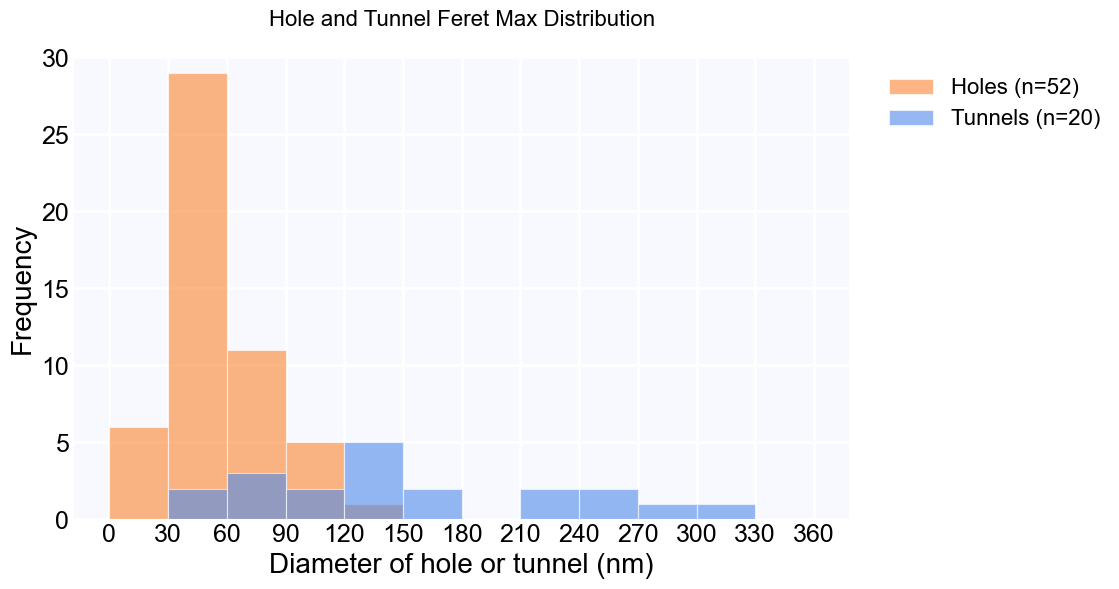


Done.


In [3]:
# ---------------------------------------------------------------
# A431 Script 2: Histogram: Feret Max (nm) for holes and tunnels
# F1 = 260503-DSM2-DSM3-indhole-COMBINED.csv
# ---------------------------------------------------------------
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import os
import re

# ------------------------------
# User Settings
# ------------------------------
input_fileF1 = "260503-DSM2-DSM3-indhole-COMBINED.csv"
substr       = "260503-DSM2-DSM3-indhole"
output_dir   = "./Output-files/"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes
# ------------------------------
title_fontsize  = 16
axis_fontsize   = 20
tick_fontsize   = 18
legend_fontsize = 16
legend_pos = (1.35, 0.9)

# ------------------------------
# Set fonts to be editable in Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize":  title_fontsize,
    "axes.labelsize":  axis_fontsize,
    "xtick.labelsize": tick_fontsize,
    "ytick.labelsize": tick_fontsize,
    "legend.fontsize": legend_fontsize,
})

# ------------------------------
# Plot appearance
# ------------------------------
plot_width      = 10
plot_height     = 6
plot_background = "ghostwhite"
bin_width       = 30
hole_color      = "#FB8531"
tunnel_color    = "#4E8AEA"
hole_alpha      = 0.6
tunnel_alpha    = 0.6
grid_color      = "white"
grid_linestyle  = "-"

# ------------------------------
# Columns
# ------------------------------
label_col = "Part of hole or tunnel"
feret_col = "Feret Max (nm)"

# ------------------------------
# Known prefixes
# ------------------------------
prefixes = ["DSM2-NKB", "DSM2-SEZ", "DSM3-COMBINED"]

# ------------------------------
# Regex patterns
# Label structure:
#   PREFIX-hole-DSMXX_LN_HM  (hole)
#   PREFIX-hole-DSMXX_LN_TM  (tunnel)
#
#   PREFIX = DSM2-NKB | DSM2-SEZ | DSM3-COMBINED
#   XX     = one or two digit DSM number
#   L      = uppercase letter (A or B)
#   N      = one or two digit subtype number (e.g. A1, B4)
#   M      = one or two digit hole/tunnel number
#
# Grouping for tunnels: (prefix, dsm_id, M)
#   -> pools all A* and B* variants with the same tunnel number M
#   -> keeps only the one with the largest Feret Max
# ------------------------------
prefix_pat = "|".join(re.escape(p) for p in prefixes)

hole_pattern = re.compile(
    rf'^({prefix_pat})-hole-(DSM\d+)_([A-Z])(\d+)_(H\d+)$',
    re.IGNORECASE
)
tunnel_pattern = re.compile(
    rf'^({prefix_pat})-hole-(DSM\d+)_([A-Z])(\d+)_(T\d+)$',
    re.IGNORECASE
)

# ------------------------------
# Load data
# ------------------------------
df = pd.read_csv(input_fileF1)
df[feret_col] = pd.to_numeric(df[feret_col], errors="coerce")

print(f"Total rows loaded: {len(df)}")
print(df[[label_col, feret_col]].head(10).to_string(index=False))

# ------------------------------
# Parse and separate holes vs tunnels
# ------------------------------
hole_records   = []
tunnel_records = []

for _, row in df.iterrows():
    label = str(row[label_col]).strip()
    feret = row[feret_col]

    # --- Try hole match ---
    m = hole_pattern.match(label)
    if m:
        prefix   = m.group(1).upper()
        dsm_id   = m.group(2).upper()
        letter   = m.group(3).upper()        # A or B
        sub_num  = int(m.group(4))           # the number after A/B e.g. 1 in A1
        hole_id  = m.group(5).upper()        # e.g. H1, H2
        hole_records.append({
            "Label":        label,
            "prefix":       prefix,
            "dsm_id":       dsm_id,
            "letter":       letter,
            "sub_num":      sub_num,
            "subtype":      f"{letter}{sub_num}",   # e.g. A1, B4
            "hole_id":      hole_id,
            "Feret_Max_nm": feret,
            "Type":         "Hole",
        })
        continue

    # --- Try tunnel match ---
    m = tunnel_pattern.match(label)
    if m:
        prefix     = m.group(1).upper()
        dsm_id     = m.group(2).upper()
        letter     = m.group(3).upper()      # A or B
        sub_num    = int(m.group(4))         # the number after A/B e.g. 4 in B4
        tunnel_id  = m.group(5).upper()      # e.g. T1, T2
        # Extract the tunnel number as int for grouping
        t_num      = int(re.search(r'\d+', tunnel_id).group())
        tunnel_records.append({
            "Label":        label,
            "prefix":       prefix,
            "dsm_id":       dsm_id,
            "letter":       letter,
            "sub_num":      sub_num,
            "subtype":      f"{letter}{sub_num}",   # e.g. A1, B4
            "tunnel_id":    tunnel_id,
            "t_num":        t_num,
            "Feret_Max_nm": feret,
            "Type":         "Tunnel",
        })

df_holes   = pd.DataFrame(hole_records)
df_tunnels = pd.DataFrame(tunnel_records)

print(f"\nHole rows parsed:   {len(df_holes)}")
print(f"Tunnel rows parsed: {len(df_tunnels)}")

# ------------------------------
# Holes: keep ALL rows
# ------------------------------
df_holes_out = df_holes[[
    "Label", "prefix", "dsm_id", "subtype",
    "hole_id", "Feret_Max_nm", "Type"
]].copy()

# ------------------------------
# Tunnels: group by (prefix, dsm_id, t_num)
# This pools ALL letter+subtype combos (A1, B4, A2, B6 etc.)
# that share the same tunnel number, and keeps the largest Feret Max
# e.g. DSM7_A1_T1 and DSM7_B4_T1 -> one group "T1", keep larger
#      DSM7_A2_T2 and DSM7_B6_T2 -> separate group "T2", keep larger
# ------------------------------
if not df_tunnels.empty:
    idx_t = (
        df_tunnels
        .groupby(["prefix", "dsm_id", "t_num"])["Feret_Max_nm"]
        .idxmax()
    )
    df_tunnels_max = df_tunnels.loc[idx_t].reset_index(drop=True)
else:
    df_tunnels_max = pd.DataFrame(columns=df_tunnels.columns)

df_tunnels_out = df_tunnels_max[[
    "Label", "prefix", "dsm_id", "subtype",
    "tunnel_id", "t_num", "Feret_Max_nm", "Type"
]].copy()

print(f"\nHoles kept (all):         {len(df_holes_out)}")
print(f"Tunnels kept (max/group): {len(df_tunnels_out)}")

# ------------------------------
# Preview
# ------------------------------
print("\nHoles preview:")
print(df_holes_out.head(10).to_string(index=False))
print("\nTunnels preview (filtered):")
print(df_tunnels_out.head(10).to_string(index=False))

# ------------------------------
# Combine for Excel output
# ------------------------------
df_holes_excel = df_holes_out[[
    "Label", "prefix", "dsm_id", "subtype", "hole_id", "Feret_Max_nm", "Type"
]].copy()
df_holes_excel = df_holes_excel.rename(columns={"hole_id": "hole_tunnel_id"})

df_tunnels_excel = df_tunnels_out[[
    "Label", "prefix", "dsm_id", "subtype", "tunnel_id", "Feret_Max_nm", "Type"
]].copy()
df_tunnels_excel = df_tunnels_excel.rename(columns={"tunnel_id": "hole_tunnel_id"})

df_combined_out = pd.concat(
    [df_holes_excel, df_tunnels_excel], ignore_index=True
)
df_combined_out = df_combined_out.sort_values(
    ["prefix", "dsm_id", "Type"]
).reset_index(drop=True)

excel_path = os.path.join(output_dir, f"{substr}_holes_tunnels_filtered.xlsx")
df_combined_out.to_excel(excel_path, index=False)
print(f"\nFiltered data saved to: {excel_path}")

# ------------------------------
# Histogram bins
# ------------------------------
all_feret = pd.concat([
    df_holes_out["Feret_Max_nm"],
    df_tunnels_out["Feret_Max_nm"]
]).dropna()

bin_min = 0
bin_max = int(np.ceil(all_feret.max() / bin_width) * bin_width) + bin_width
bins    = np.arange(bin_min, bin_max + bin_width, bin_width)

# ------------------------------
# Plot histogram
# ------------------------------
fig, ax = plt.subplots(figsize=(plot_width, plot_height))
ax.set_facecolor(plot_background)
ax.set_axisbelow(True)
ax.tick_params(axis="both", which="major", length=0, labelsize=tick_fontsize)

ax.hist(
    df_holes_out["Feret_Max_nm"].dropna(),
    bins=bins,
    color=hole_color,
    alpha=hole_alpha,
    edgecolor="white",
    linewidth=0.8,
    label=f"Holes (n={len(df_holes_out)})",
    zorder=2,
)

ax.hist(
    df_tunnels_out["Feret_Max_nm"].dropna(),
    bins=bins,
    color=tunnel_color,
    alpha=tunnel_alpha,
    edgecolor="white",
    linewidth=0.8,
    label=f"Tunnels (n={len(df_tunnels_out)})",
    zorder=3,
)

ax.set_ylim(0, 30)
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_major_locator(ticker.MultipleLocator(bin_width))

ax.set_xlabel("Diameter of hole or tunnel (nm)", fontsize=axis_fontsize)
ax.set_ylabel("Frequency", fontsize=axis_fontsize)
ax.set_title(
    "Hole and Tunnel Feret Max Distribution\n",
    fontsize=title_fontsize
)

ax.legend(loc="center right", frameon=False, bbox_to_anchor=legend_pos, fontsize=legend_fontsize)

ax.grid(True, linestyle=grid_linestyle, color=grid_color,
        linewidth=2, alpha=1, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)

for ext in ["png", "pdf"]:
    fig.savefig(os.path.join(output_dir, f"{substr}_histogram.{ext}"),
                dpi=300, bbox_inches="tight")

plt.show()
print("\nDone.")


Matched rows (max diameter vs max hole, one per ODP subtype): 15
                     F1_Name  ODP_Diameter_nm    Shapes                           F2_Name  Hole_Diameter_nm  Diameter_Hole_Ratio
  A_left-260419-FINAL DSM1_B       550.619542     Ovoid  A_left-hole-260419-FINAL DSM1_B1         84.088249             6.548115
  A_left-260419-FINAL DSM2_A       447.773172     Ovoid  A_left-hole-260419-FINAL DSM2_A1         37.245722            12.022137
  A_left-260419-FINAL DSM3_B      1229.840000 Irregular  A_left-hole-260419-FINAL DSM3_B1         70.448219            17.457361
  A_left-260419-FINAL DSM4_A       621.475313     Ovoid  A_left-hole-260419-FINAL DSM4_A1         39.396387            15.774932
A_right-260419-FINAL DSM1_Aa      1770.630000 Irregular A_right-hole-260419-FINAL DSM1_A4        331.709787             5.337889
 A_right-260419-FINAL DSM1_B      3219.830000 Irregular A_right-hole-260419-FINAL DSM1_B5        263.839228            12.203758
       C_260419-FINAL DSM1_B   

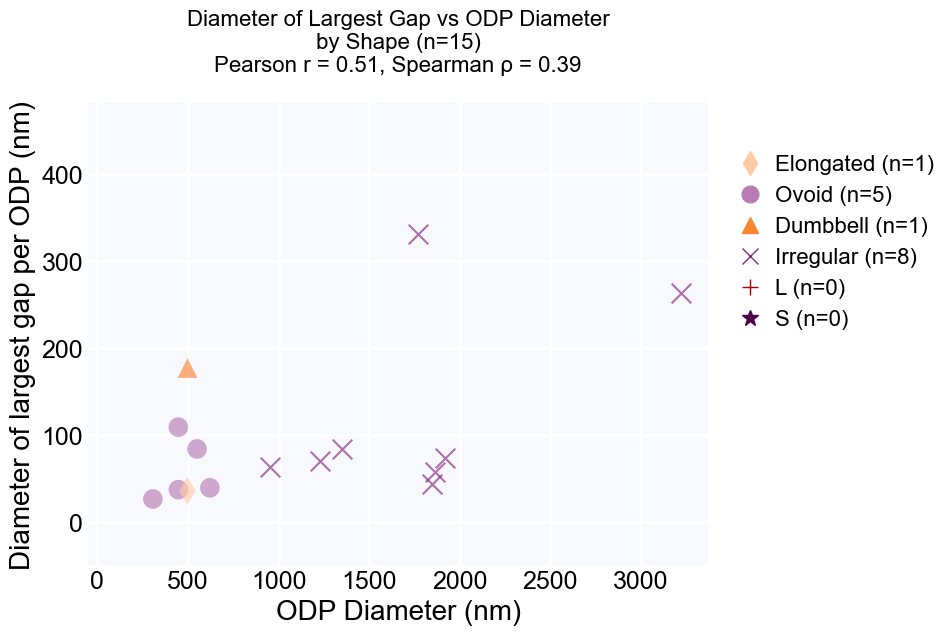

(0.5114829142735389, 0.3857142857142856)

In [4]:
# ---------------------------------------------------------------
# S1 Script 1: Hole diameter vs ODP diameter (S1 HMEC, max-only)
# ---------------------------------------------------------------
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr
import matplotlib.lines as mlines
import numpy as np
import matplotlib

# ------------------------------
# User Settings
# ------------------------------
input_fileF1 = "260503-S1-HMEC-indODP-COMBINED.csv"
input_fileF2 = "260503-S1-HMEC-hole-COMBINED.csv"
substr = "260503-S1-HMEC"
output_dir = "./Output-files/"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes
# ------------------------------
title_fontsize = 16
axis_fontsize = 20
tick_fontsize = 18
legend_fontsize = 16

# ------------------------------
# Set fonts to be editable in Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize": title_fontsize,
    "axes.labelsize": axis_fontsize,
    "xtick.labelsize": tick_fontsize,
    "ytick.labelsize": tick_fontsize,
    "legend.fontsize": legend_fontsize,
})

# Scatter point transparency
alpha_val = 0.55
alpha_val_shape = 0.65

# Legend
legend_pos = (1, 0.7)
marker_size = 12

# Plot background color
background_color = "ghostwhite"

# ------------------------------
# Columns
# ------------------------------
f1_name_col     = "Name (NA)_match"
f1_diameter_col = "Corrected length"
f1_shapes_col   = "Shapes"

f2_name_col     = "Name (NA)_hole"
f2_feret_col    = "Feret Max (nm)"

# ------------------------------
# Prefix maps: F1 prefix -> F2 prefix
# ------------------------------
# F1 prefixes
f1_prefixes = [
    "A_left-260419-FINAL ",
    "A_right-260419-FINAL ",
    "C_260419-FINAL ",
    "MA-260419-FINAL ",
]
# Corresponding F2 prefixes (same order)
f2_prefixes = [
    "A_left-hole-260419-FINAL ",
    "A_right-hole-260419-FINAL ",
    "C_hole-260419-FINAL ",
    "MA-hole-260419-FINAL ",
]
# Map F1 prefix -> F2 prefix
f1_to_f2_prefix = dict(zip(f1_prefixes, f2_prefixes))
# Map F2 prefix -> F1 prefix (for reverse lookup)
f2_to_f1_prefix = dict(zip(f2_prefixes, f1_prefixes))

# ------------------------------
# Load data
# ------------------------------
df_f1 = pd.read_csv(input_fileF1)
df_f2 = pd.read_csv(input_fileF2)

# ------------------------------
# Parsing helpers
# ------------------------------
# F1: PREFIX-DSMXX_AA  e.g. A_left-260419-FINAL-DSM7_A or A_left-260419-FINAL-DSM7_Ab
# Build pattern from known prefixes (escaped)
f1_prefix_pattern = "|".join(re.escape(p) for p in f1_prefixes)
f1_pattern = re.compile(
    rf'^({f1_prefix_pattern})(DSM\d+)_([A-Z][a-z]?)$',
    re.IGNORECASE
)

# F2: PREFIX-DSMYY_Az  e.g. A_left-hole-260419-FINAL-DSM7_A1
f2_prefix_pattern = "|".join(re.escape(p) for p in f2_prefixes)
f2_pattern = re.compile(
    rf'^({f2_prefix_pattern})(DSM\d+)_([A-Z])(\d+)$',
    re.IGNORECASE
)

def parse_f1_label(label):
    m = f1_pattern.match(str(label).strip())
    if not m:
        return None
    prefix, dsm_id, subtype = m.group(1), m.group(2), m.group(3)
    return {
        "prefix": prefix.upper(),
        "dsm_id": dsm_id.upper(),
        "subtype": subtype,
        "letter": subtype[0].upper(),
    }

def parse_f2_label(label):
    m = f2_pattern.match(str(label).strip())
    if not m:
        return None
    prefix, dsm_id, letter, num = m.group(1), m.group(2), m.group(3), m.group(4)
    # Normalise F2 prefix to its F1 equivalent for matching
    f1_equiv = f2_to_f1_prefix.get(prefix, f2_to_f1_prefix.get(prefix.upper(), prefix))
    # Case-insensitive lookup
    f1_equiv = next(
        (v for k, v in f2_to_f1_prefix.items() if k.upper() == prefix.upper()),
        prefix
    )
    return {
        "prefix":   f1_equiv.upper(),
        "dsm_id":   dsm_id.upper(),
        "letter":   letter.upper(),
        "num":      int(num),
    }

# ------------------------------
# Parse F1 — keep max diameter per (prefix, dsm_id, letter)
# ------------------------------
f1_records = []
for _, row in df_f1.iterrows():
    parsed = parse_f1_label(row[f1_name_col])
    if parsed is None:
        continue
    f1_records.append({
        "f1_name":  row[f1_name_col],
        "prefix":   parsed["prefix"],
        "dsm_id":   parsed["dsm_id"],
        "letter":   parsed["letter"],
        "diameter": row[f1_diameter_col],
        "shape":    row[f1_shapes_col],
    })

df_f1_parsed = pd.DataFrame(f1_records)

df_f1_max = (
    df_f1_parsed
    .sort_values("diameter", ascending=False)
    .groupby(["prefix", "dsm_id", "letter"], as_index=False)
    .first()
)

f1_lookup = {
    (r["prefix"], r["dsm_id"], r["letter"]): r
    for _, r in df_f1_max.iterrows()
}

# ------------------------------
# Parse F2 — keep max Feret per (prefix, dsm_id, letter)
# ------------------------------
f2_records = []
for _, row in df_f2.iterrows():
    parsed = parse_f2_label(row[f2_name_col])
    if parsed is None:
        continue
    f2_records.append({
        "f2_name": row[f2_name_col],
        "prefix":  parsed["prefix"],
        "dsm_id":  parsed["dsm_id"],
        "letter":  parsed["letter"],
        "feret":   row[f2_feret_col],
    })

df_f2_parsed = pd.DataFrame(f2_records)

df_f2_max = (
    df_f2_parsed
    .sort_values("feret", ascending=False)
    .groupby(["prefix", "dsm_id", "letter"], as_index=False)
    .first()
)

# ------------------------------
# Match F1 max to F2 max
# ------------------------------
matched_rows = []
for _, f2_row in df_f2_max.iterrows():
    key = (f2_row["prefix"], f2_row["dsm_id"], f2_row["letter"])
    if key not in f1_lookup:
        continue
    f1_row = f1_lookup[key]
    diameter = f1_row["diameter"]
    feret    = f2_row["feret"]
    ratio    = diameter / feret if feret and feret != 0 else np.nan
    matched_rows.append({
        "F1_Name":             f1_row["f1_name"],
        "ODP_Diameter_nm":     diameter,
        "Shapes":              f1_row["shape"],
        "F2_Name":             f2_row["f2_name"],
        "Hole_Diameter_nm":    feret,
        "Diameter_Hole_Ratio": ratio,
    })

matched_df = pd.DataFrame(matched_rows)

# ------------------------------
# Print preview
# ------------------------------
print(f"\nMatched rows (max diameter vs max hole, one per ODP subtype): {len(matched_df)}")
print(matched_df.head(10).to_string(index=False))

# ------------------------------
# Save to Excel
# ------------------------------
excel_out = os.path.join(output_dir, f"{substr}_HoleDia_vs_ODPDia.xlsx")
matched_df.to_excel(excel_out, index=False)
print(f"\nData saved to: {excel_out}")

# ------------------------------
# Counts from matched_df
# ------------------------------
shapes_counts = matched_df["Shapes"].value_counts()

# ------------------------------
# Color/marker maps: Shapes
# ------------------------------
shapes_colors = ["#FFCBA5", "#B77CB4", "#FB8531", "#86277F", "#AD0000", "#4E0049"]
shapes_color_map = {
    "Elongated":  shapes_colors[0],
    "Ovoid":      shapes_colors[1],
    "Dumbbell":   shapes_colors[2],
    "Irregular":  shapes_colors[3],
    "L":          shapes_colors[4],
    "S":          shapes_colors[5],
}
shapes_marker_map = {
    "Elongated":  "d",
    "Ovoid":      "o",
    "Dumbbell":   "^",
    "Irregular":  "x",
    "L":          "+",
    "S":          "*",
}
shapes_handles = [
    mlines.Line2D([], [], color=shapes_colors[0], marker="d", linestyle="None",
                  markersize=marker_size, label=f"Elongated (n={shapes_counts.get('Elongated', 0)})"),
    mlines.Line2D([], [], color=shapes_colors[1], marker="o", linestyle="None",
                  markersize=marker_size, label=f"Ovoid (n={shapes_counts.get('Ovoid', 0)})"),
    mlines.Line2D([], [], color=shapes_colors[2], marker="^", linestyle="None",
                  markersize=marker_size, label=f"Dumbbell (n={shapes_counts.get('Dumbbell', 0)})"),
    mlines.Line2D([], [], color=shapes_colors[3], marker="x", linestyle="None",
                  markersize=marker_size, label=f"Irregular (n={shapes_counts.get('Irregular', 0)})"),
    mlines.Line2D([], [], color=shapes_colors[4], marker="+", linestyle="None",
                  markersize=marker_size, label=f"L (n={shapes_counts.get('L', 0)})"),
    mlines.Line2D([], [], color=shapes_colors[5], marker="*", linestyle="None",
                  markersize=marker_size, label=f"S (n={shapes_counts.get('S', 0)})"),
]

# ------------------------------
# Helper: compute axis limits
# ------------------------------
def make_limits(series):
    return (-50, series.dropna().max() + 150)

# ------------------------------
# Plot function: Hole diameter vs ODP diameter
# ------------------------------
def plot_hole_vs_odp(data, encode_col, color_map, marker_map, legend_handles,
                     title, filename, alpha=0.55, legend_pos=(1, 0.7),
                     xlim=None, ylim=None, background_color="ghostwhite"):

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.set_facecolor(background_color)

    x_col = "ODP_Diameter_nm"
    y_col = "Hole_Diameter_nm"

    for val in data[encode_col].unique():
        subset = data[data[encode_col] == val]
        if val not in color_map:
            continue
        marker = marker_map[val]
        color  = color_map[val]
        if marker in ["x", "+", "|", "_"]:
            ax.scatter(subset[x_col], subset[y_col],
                       color=color, marker=marker,
                       s=200, alpha=alpha, zorder=2)
        else:
            ax.scatter(subset[x_col], subset[y_col],
                       facecolor=color, edgecolor="none", marker=marker,
                       s=200, alpha=alpha, zorder=2)

    valid = data[[x_col, y_col]].dropna()
    if len(valid) >= 3:
        r_pearson,    _ = pearsonr(valid[x_col], valid[y_col])
        rho_spearman, _ = spearmanr(valid[x_col], valid[y_col])
    else:
        r_pearson = rho_spearman = np.nan

    n_points = len(data)
    ax.set_xlabel("ODP Diameter (nm)")
    ax.set_ylabel("Diameter of largest gap per ODP (nm)")
    ax.set_title(
        f"{title} (n={n_points})\n"
        f"Pearson r = {r_pearson:.2f}, Spearman ρ = {rho_spearman:.2f}\n"
    )

    if xlim: ax.set_xlim(xlim)
    if ylim: ax.set_ylim(ylim)

    ax.tick_params(axis="both", which="both", length=0)
    ax.grid(True, linestyle="-", color="white", linewidth=2, alpha=1, zorder=0)
    for spine in ax.spines.values():
        spine.set_visible(False)

    ax.legend(handles=legend_handles, loc="center left",
              bbox_to_anchor=legend_pos, handletextpad=0.1, frameon=False)

    for ext in ["png", "pdf"]:
        fig.savefig(os.path.join(output_dir, f"{filename}.{ext}"),
                    dpi=300, bbox_inches="tight")
    plt.show()
    return r_pearson, rho_spearman
# ------------------------------
# Compute axis limits
# ------------------------------
x_lim_dia = make_limits(matched_df["ODP_Diameter_nm"])
y_lim_dia  = make_limits(matched_df["Hole_Diameter_nm"])


# ------------------------------
# Plot 1: Shapes — Hole diameter vs ODP diameter
# ------------------------------
plot_hole_vs_odp(
    matched_df,
    encode_col="Shapes",
    color_map=shapes_color_map,
    marker_map=shapes_marker_map,
    legend_handles=shapes_handles,
    title="Diameter of Largest Gap vs ODP Diameter\nby Shape",
    filename=substr + "-HoleDia_vs_ODPDia_Shapes",
    alpha=alpha_val_shape,
    legend_pos=legend_pos,
    xlim=x_lim_dia,
    ylim=y_lim_dia,
    background_color=background_color
)

Total rows loaded: 30
              Part of hole or tunnel  Feret Max (nm)
      C_hole-260419-FINAL DSM7_B1_H4       23.872627
      C_hole-260419-FINAL DSM2_A1_H1       26.500061
      C_hole-260419-FINAL DSM1_B1_H1       36.087820
 A_left-hole-260419-FINAL DSM2_A1_H1       37.245722
A_right-hole-260419-FINAL DSM1_A6_T1      208.454826
 A_left-hole-260419-FINAL DSM4_A1_H1       39.396387
      C_hole-260419-FINAL DSM5_A1_H1       43.576177
      C_hole-260419-FINAL DSM7_A2_H2       44.610171
A_right-hole-260419-FINAL DSM1_A5_T2      245.450266
     MA-hole-260419-FINAL DSM1_B2_T1       53.127184

Hole rows parsed:   20
Tunnel rows parsed: 10

Holes kept (all):         20
Tunnels kept (max/group): 5

Holes preview:
                              Label                    prefix dsm_id subtype hole_id  Feret_Max_nm Type
     C_hole-260419-FINAL DSM7_B1_H4      C_HOLE-260419-FINAL    DSM7      B1      H4     23.872627 Hole
     C_hole-260419-FINAL DSM2_A1_H1      C_HOLE-260419-FINAL    DS

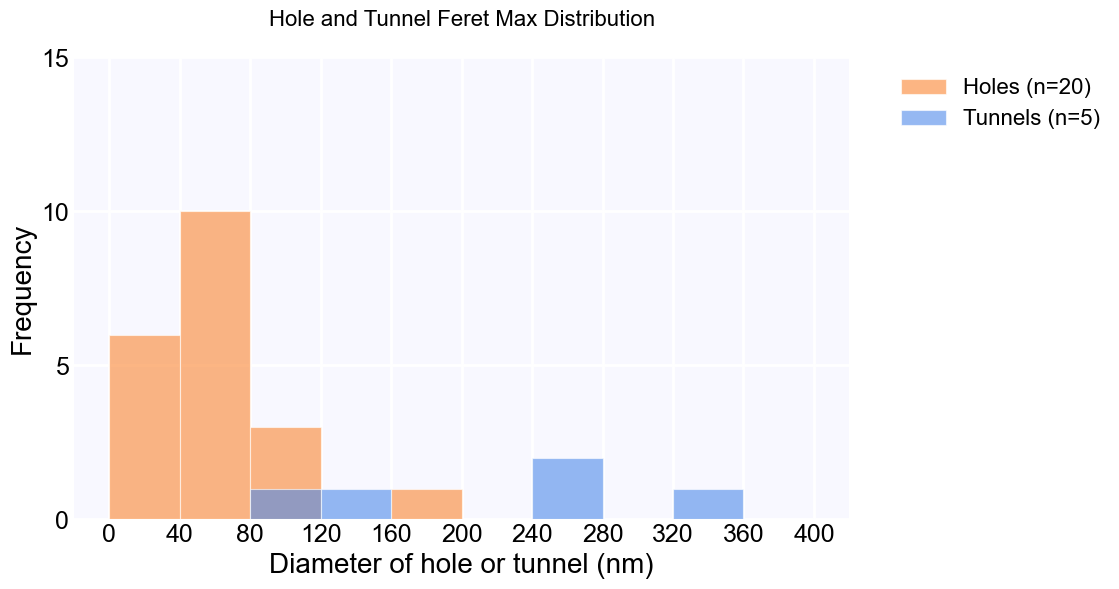


Done.


In [6]:
# ---------------------------------------------------------------
# S1 Script 2: Histogram: Feret Max (nm) for holes and tunnels
# F1 = 260503-S1-HMEC-indhole-COMBINED.csv
# ---------------------------------------------------------------
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import os
import re

# ------------------------------
# User Settings
# ------------------------------
input_fileF1 = "260503-S1-HMEC-indhole-COMBINED.csv"
substr       = "260503-S1-HMEC-indhole"
output_dir   = "./Output-files/"
os.makedirs(output_dir, exist_ok=True)

# ------------------------------
# Font sizes
# ------------------------------
title_fontsize  = 16
axis_fontsize   = 20
tick_fontsize   = 18
legend_fontsize = 16
legend_pos = (1.35, 0.9)

# ------------------------------
# Set fonts to be editable in Illustrator
# ------------------------------
matplotlib.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "Arial",
    "axes.titlesize":  title_fontsize,
    "axes.labelsize":  axis_fontsize,
    "xtick.labelsize": tick_fontsize,
    "ytick.labelsize": tick_fontsize,
    "legend.fontsize": legend_fontsize,
})

# ------------------------------
# Plot appearance
# ------------------------------
plot_width      = 10
plot_height     = 6
plot_background = "ghostwhite"
bin_width       = 40
hole_color      = "#FB8531"
tunnel_color    = "#4E8AEA"
hole_alpha      = 0.6
tunnel_alpha    = 0.6
grid_color      = "white"
grid_linestyle  = "-"

# ------------------------------
# Columns
# ------------------------------
label_col = "Part of hole or tunnel"
feret_col = "Feret Max (nm)"

# ------------------------------
# Known prefixes
# ------------------------------
prefixes = [
    "A_left-hole-260419-FINAL ",
    "A_right-hole-260419-FINAL ",
    "C_hole-260419-FINAL ",
    "MA-hole-260419-FINAL ",
]

# ------------------------------
# Regex patterns
# Label structure:
#   PREFIX-DSMXX_LN_HM  (hole)
#   PREFIX-DSMXX_LN_TM  (tunnel)
#
#   PREFIX = A_left-hole-260419-FINAL | A_right-hole-260419-FINAL |
#            C_hole-260419-FINAL | MA-hole-260419-FINAL
#   XX     = one or two digit DSM number
#   L      = uppercase letter (A or B)
#   N      = one or more digit subtype number (e.g. A1, B4)
#   M      = one or more digit hole/tunnel number
#
# Grouping for tunnels: (prefix, dsm_id, t_num)
#   -> pools all A* and B* variants with the same tunnel number
#   -> keeps only the one with the largest Feret Max
# ------------------------------
prefix_pat = "|".join(re.escape(p) for p in prefixes)

hole_pattern = re.compile(
    rf'^({prefix_pat})(DSM\d+)_([A-Z])(\d+)_(H\d+)$',
    re.IGNORECASE
)
tunnel_pattern = re.compile(
    rf'^({prefix_pat})(DSM\d+)_([A-Z])(\d+)_(T\d+)$',
    re.IGNORECASE
)

# ------------------------------
# Load data
# ------------------------------
df = pd.read_csv(input_fileF1)
df[feret_col] = pd.to_numeric(df[feret_col], errors="coerce")

print(f"Total rows loaded: {len(df)}")
print(df[[label_col, feret_col]].head(10).to_string(index=False))

# ------------------------------
# Parse and separate holes vs tunnels
# ------------------------------
hole_records   = []
tunnel_records = []

for _, row in df.iterrows():
    label = str(row[label_col]).strip()
    feret = row[feret_col]

    # --- Try hole match ---
    m = hole_pattern.match(label)
    if m:
        prefix  = m.group(1).upper()
        dsm_id  = m.group(2).upper()
        letter  = m.group(3).upper()
        sub_num = int(m.group(4))
        hole_id = m.group(5).upper()
        hole_records.append({
            "Label":        label,
            "prefix":       prefix,
            "dsm_id":       dsm_id,
            "letter":       letter,
            "sub_num":      sub_num,
            "subtype":      f"{letter}{sub_num}",
            "hole_id":      hole_id,
            "Feret_Max_nm": feret,
            "Type":         "Hole",
        })
        continue

    # --- Try tunnel match ---
    m = tunnel_pattern.match(label)
    if m:
        prefix    = m.group(1).upper()
        dsm_id    = m.group(2).upper()
        letter    = m.group(3).upper()
        sub_num   = int(m.group(4))
        tunnel_id = m.group(5).upper()
        t_num     = int(re.search(r'\d+', tunnel_id).group())
        tunnel_records.append({
            "Label":        label,
            "prefix":       prefix,
            "dsm_id":       dsm_id,
            "letter":       letter,
            "sub_num":      sub_num,
            "subtype":      f"{letter}{sub_num}",
            "tunnel_id":    tunnel_id,
            "t_num":        t_num,
            "Feret_Max_nm": feret,
            "Type":         "Tunnel",
        })

df_holes   = pd.DataFrame(hole_records)
df_tunnels = pd.DataFrame(tunnel_records)

print(f"\nHole rows parsed:   {len(df_holes)}")
print(f"Tunnel rows parsed: {len(df_tunnels)}")

# ------------------------------
# Holes: keep ALL rows
# ------------------------------
df_holes_out = df_holes[[
    "Label", "prefix", "dsm_id", "subtype",
    "hole_id", "Feret_Max_nm", "Type"
]].copy()

# ------------------------------
# Tunnels: group by (prefix, dsm_id, t_num)
# pools all A* and B* variants sharing the same tunnel number
# keeps the one with the largest Feret Max per group
# ------------------------------
if not df_tunnels.empty:
    idx_t = (
        df_tunnels
        .groupby(["prefix", "dsm_id", "t_num"])["Feret_Max_nm"]
        .idxmax()
    )
    df_tunnels_max = df_tunnels.loc[idx_t].reset_index(drop=True)
else:
    df_tunnels_max = pd.DataFrame(columns=df_tunnels.columns)

df_tunnels_out = df_tunnels_max[[
    "Label", "prefix", "dsm_id", "subtype",
    "tunnel_id", "t_num", "Feret_Max_nm", "Type"
]].copy()

print(f"\nHoles kept (all):         {len(df_holes_out)}")
print(f"Tunnels kept (max/group): {len(df_tunnels_out)}")

# ------------------------------
# Preview
# ------------------------------
print("\nHoles preview:")
print(df_holes_out.head(10).to_string(index=False))
print("\nTunnels preview (filtered):")
print(df_tunnels_out.head(10).to_string(index=False))

# ------------------------------
# Combine for Excel output
# ------------------------------
df_holes_excel = df_holes_out[[
    "Label", "prefix", "dsm_id", "subtype", "hole_id", "Feret_Max_nm", "Type"
]].copy()
df_holes_excel = df_holes_excel.rename(columns={"hole_id": "hole_tunnel_id"})

df_tunnels_excel = df_tunnels_out[[
    "Label", "prefix", "dsm_id", "subtype", "tunnel_id", "Feret_Max_nm", "Type"
]].copy()
df_tunnels_excel = df_tunnels_excel.rename(columns={"tunnel_id": "hole_tunnel_id"})

df_combined_out = pd.concat(
    [df_holes_excel, df_tunnels_excel], ignore_index=True
)
df_combined_out = df_combined_out.sort_values(
    ["prefix", "dsm_id", "Type"]
).reset_index(drop=True)

excel_path = os.path.join(output_dir, f"{substr}_holes_tunnels_filtered.xlsx")
df_combined_out.to_excel(excel_path, index=False)
print(f"\nFiltered data saved to: {excel_path}")

# ------------------------------
# Histogram bins
# ------------------------------
all_feret = pd.concat([
    df_holes_out["Feret_Max_nm"],
    df_tunnels_out["Feret_Max_nm"]
]).dropna()

bin_min = 0
bin_max = int(np.ceil(all_feret.max() / bin_width) * bin_width) + bin_width
bins    = np.arange(bin_min, bin_max + bin_width, bin_width)

# ------------------------------
# Plot histogram
# ------------------------------
fig, ax = plt.subplots(figsize=(plot_width, plot_height))
ax.set_facecolor(plot_background)
ax.set_axisbelow(True)
ax.tick_params(axis="both", which="major", length=0, labelsize=tick_fontsize)

ax.hist(
    df_holes_out["Feret_Max_nm"].dropna(),
    bins=bins,
    color=hole_color,
    alpha=hole_alpha,
    edgecolor="white",
    linewidth=0.8,
    label=f"Holes (n={len(df_holes_out)})",
    zorder=2,
)

ax.hist(
    df_tunnels_out["Feret_Max_nm"].dropna(),
    bins=bins,
    color=tunnel_color,
    alpha=tunnel_alpha,
    edgecolor="white",
    linewidth=0.8,
    label=f"Tunnels (n={len(df_tunnels_out)})",
    zorder=3,
)

ax.set_ylim(0, 15)
ax.yaxis.set_major_locator(ticker.MultipleLocator(5))
ax.xaxis.set_major_locator(ticker.MultipleLocator(bin_width))

ax.set_xlabel("Diameter of hole or tunnel (nm)", fontsize=axis_fontsize)
ax.set_ylabel("Frequency", fontsize=axis_fontsize)
ax.set_title(
    "Hole and Tunnel Feret Max Distribution\n",
    fontsize=title_fontsize
)

ax.legend(loc="center right", frameon=False, bbox_to_anchor=legend_pos, fontsize=legend_fontsize)

ax.grid(True, linestyle=grid_linestyle, color=grid_color,
        linewidth=2, alpha=1, zorder=0)
for spine in ax.spines.values():
    spine.set_visible(False)

for ext in ["png", "pdf"]:
    fig.savefig(os.path.join(output_dir, f"{substr}_histogram.{ext}"),
                dpi=300, bbox_inches="tight")

plt.show()
print("\nDone.")